<a href="https://colab.research.google.com/github/veljkoristic/MachineLearning1/blob/master/Projekat_Vukota_Goranovic_Veljko_Ristic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import datasets
from scipy import stats

# Analiza podataka


In [ ]:
df = pd.read_csv('final_data.csv') #ucitavanje baze

In [ ]:
df.head() #prikaz prvih 5 uzoraka iz baze sa svojim obelezjima

,first,last,team,year,games_played,min,fgm,fga,fg3m,fg3a,...,reb,ast,stl,blk,turnover,pf,pts,fg_pct,fg3_pct,ft_pct
0,Julius,Erving,PHI,1980,82.0,35:02:00,9.68,18.59,0.05,0.22,...,8.01,4.44,2.62,1.73,3.40,2.84,24.56,0.521,0.220,0.787
1,Eddie,Johnson,ATL,1980,75.0,35:55:00,7.64,15.16,0.08,0.32,...,2.39,5.47,1.54,0.11,2.70,2.53,19.08,0.504,0.249,0.784
2,Artis,Gilmore,CHI,1980,81.0,34:31:00,6.67,9.93,0.00,0.00,...,10.06,2.15,0.77,2.43,3.31,3.58,17.89,0.672,0.000,0.706
3,Reggie,Theus,CHI,1980,81.0,34:20:00,6.58,13.38,0.22,1.09,...,3.56,5.41,1.73,0.28,3.65,3.14,18.84,0.492,0.203,0.808
4,Larry,Bird,BOS,1980,82.0,39:30:00,8.77,18.33,0.24,0.92,...,10.91,5.50,2.61,0.84,3.69,2.91,21.23,0.478,0.266,0.863


In [ ]:
df.shape #broj vrsta i kolona, tj. broj uzoraka i obelezja u bazi

(1003, 24)

In [ ]:
#proveramo broj nedostajucih vrednosti u bazi, ukupno i procentualno

total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/len(df)).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
oreb,1,0.000997
dreb,1,0.000997
fg3_pct,1,0.000997
fg_pct,1,0.000997
pts,1,0.000997
pf,1,0.000997
turnover,1,0.000997
blk,1,0.000997
stl,1,0.000997
ast,1,0.000997


In [ ]:
df.isnull().sum()

first           0
last            0
team            0
year            0
games_played    1
min             1
fgm             1
fga             1
fg3m            1
fg3a            1
ftm             1
fta             1
oreb            1
dreb            1
reb             1
ast             1
stl             1
blk             1
turnover        1
pf              1
pts             1
fg_pct          1
fg3_pct         1
ft_pct          1
dtype: int64

In [ ]:
#prikazali smo da se kod samo jednog uzorka (kod samo jednog igraca), javljaju sve nedostajuce vrednosti u bazi, pa cemo tog igraca
#izbaciti iz baze

df1 = df[df.isnull().any(axis=1)]
print(df1)

     first     last team  year  games_played  min  fgm  fga  fg3m  fg3a  ...  \
261  Magic  Johnson  LAL  1991           NaN  NaN  NaN  NaN   NaN   NaN  ...   

     reb  ast  stl  blk  turnover  pf  pts  fg_pct  fg3_pct  ft_pct  
261  NaN  NaN  NaN  NaN       NaN NaN  NaN     NaN      NaN     NaN  

[1 rows x 24 columns]


In [ ]:
df.dropna(inplace = True, axis=0)

In [ ]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/len(df)).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
first,0,0.0
last,0,0.0
fg3_pct,0,0.0
fg_pct,0,0.0
pts,0,0.0
pf,0,0.0
turnover,0,0.0
blk,0,0.0
stl,0,0.0
ast,0,0.0


In [ ]:
df.shape #prikaz dimenzionalnosti nakon izbacivanja nedostajucih podataka

(1002, 24)

In [ ]:
#ono sto mi radimo je procena prosecnog broja licnih gresaka, funkcijom describe saznajemo neke detalje o ovom obelezju

df['pf'].describe()

count    1002.000000
mean        2.599770
std         0.633464
min         0.850000
25%         2.112500
50%         2.575000
75%         3.067500
max         4.190000
Name: pf, dtype: float64

In [ ]:
df[df['pf'] == 0.85]

,first,last,team,year,games_played,min,fgm,fga,fg3m,fg3a,...,reb,ast,stl,blk,turnover,pf,pts,fg_pct,fg3_pct,ft_pct
728,Steve,Nash,PHO,2011,62.0,31:36:00,4.76,8.95,0.89,2.27,...,3.0,10.71,0.61,0.13,3.69,0.85,12.45,0.532,0.39,0.894


In [ ]:
df[df['pf'] == 4.19]

,first,last,team,year,games_played,min,fgm,fga,fg3m,fg3a,...,reb,ast,stl,blk,turnover,pf,pts,fg_pct,fg3_pct,ft_pct
297,Shawn,Kemp,SEA,1992,78.0,33:06:00,6.6,13.42,0.0,0.05,...,10.68,1.99,1.53,1.87,2.78,4.19,17.79,0.492,0.0,0.712


In [ ]:
#vidimo da cemo posmatrati sezone od 1980. do 2022., ali bez 1998.podaci iz 1998. godine nedostaju zbog NBA lokauta

df['year'].unique()

array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [ ]:
df['pf'].unique()

array([2.84, 2.53, 3.58, 3.14, 2.91, 3.78, 2.5 , 3.27, 2.58, 2.75, 2.43,
       1.94, 2.59, 3.05, 2.46, 3.07, 3.09, 2.79, 2.68, 3.44, 2.42, 2.83,
       3.17, 1.93, 3.51, 3.5 , 3.54, 3.36, 3.89, 2.94, 2.78, 2.85, 2.72,
       2.04, 2.95, 3.91, 2.87, 3.26, 2.61, 3.23, 3.16, 3.61, 3.18, 3.94,
       2.49, 2.81, 2.64, 2.3 , 2.37, 3.29, 3.15, 3.43, 3.93, 3.56, 1.89,
       1.98, 3.32, 2.76, 1.48, 3.12, 2.41, 3.95, 2.82, 3.33, 3.55, 3.21,
       3.8 , 2.96, 2.52, 2.88, 3.67, 2.4 , 1.91, 4.13, 3.11, 2.  , 3.73,
       2.89, 3.03, 1.14, 2.16, 4.16, 2.35, 2.73, 2.6 , 2.55, 3.48, 3.47,
       2.7 , 3.34, 3.38, 2.8 , 3.76, 2.77, 2.22, 2.62, 2.44, 2.65, 2.18,
       1.95, 2.25, 1.85, 3.9 , 1.68, 2.9 , 3.6 , 4.  , 3.37, 2.1 , 3.74,
       2.51, 3.92, 1.78, 3.04, 2.33, 2.63, 1.9 , 2.28, 3.1 , 3.71, 3.45,
       1.6 , 2.07, 2.08, 2.03, 4.05, 3.4 , 2.97, 1.47, 4.1 , 3.66, 2.12,
       4.01, 3.35, 2.17, 3.3 , 1.73, 1.31, 3.31, 2.86, 2.26, 2.24, 2.54,
       3.96, 2.31, 2.39, 1.72, 1.76, 2.13, 3.63, 3.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41],
 [Text(0, 0, '1980'),
  Text(1, 0, '1981'),
  Text(2, 0, '1982'),
  Text(3, 0, '1983'),
  Text(4, 0, '1984'),
  Text(5, 0, '1985'),
  Text(6, 0, '1986'),
  Text(7, 0, '1987'),
  Text(8, 0, '1988'),
  Text(9, 0, '1989'),
  Text(10, 0, '1990'),
  Text(11, 0, '1991'),
  Text(12, 0, '1992'),
  Text(13, 0, '1993'),
  Text(14, 0, '1994'),
  Text(15, 0, '1995'),
  Text(16, 0, '1996'),
  Text(17, 0, '1997'),
  Text(18, 0, '1999'),
  Text(19, 0, '2000'),
  Text(20, 0, '2001'),
  Text(21, 0, '2002'),
  Text(22, 0, '2003'),
  Text(23, 0, '2004'),
  Text(24, 0, '2005'),
  Text(25, 0, '2006'),
  Text(26, 0, '2007'),
  Text(27, 0, '2008'),
  Text(28, 0, '2009'),
  Text(29, 0, '2010'),
  Text(30, 0, '2011'),
  Text(31, 0, '2012'),
  Text(32, 0, '2013'),
  Text(3

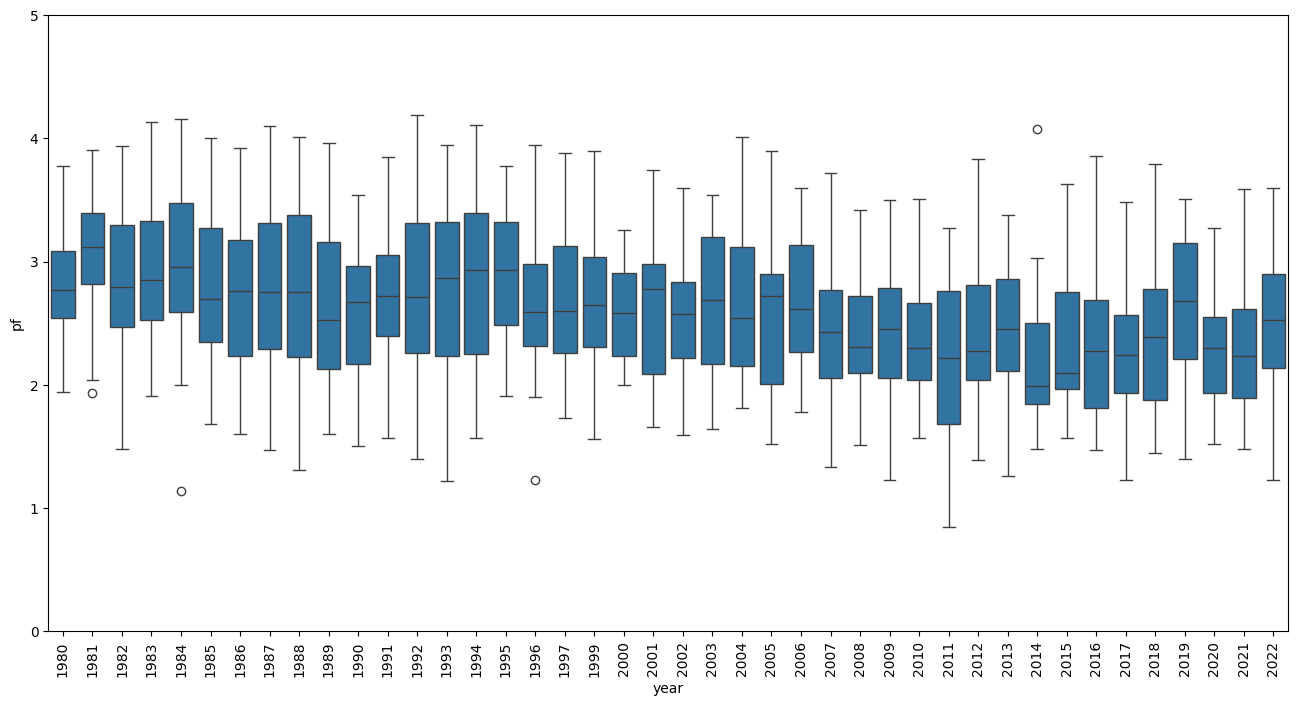

In [ ]:
#proveravamo da li imamo autlajere, napravicemo novi data frame u kome ce se nalaziti samo licne greske i godine i crtamo boxplot
#na x osi su godine (sezone), na y osi licne greske
#funkcijom describe videli smo da je maksimalan prosecan broj licnih gresaka po sezoni 4.2 (sto je i ocekivano zbog pravila u kosarci-> ne vise od 5), a minimalan broj 0.85

data1 = pd.concat([df['pf'], df['year']], axis=1)
f = plt.figure(figsize=(16, 8))
fig = sns.boxplot(x='year', y='pf', data=data1)
fig.axis(ymin=0, ymax=5)
plt.xticks(rotation=90)

In [ ]:
df['team'].unique()

array(['PHI', 'ATL', 'CHI', 'BOS', 'NYK', 'MIL', 'CLE', 'SEA', 'SAS',
       'LAL', 'PHO', 'UTA', 'HOU', 'KCK', 'DET', 'NJN', 'GSW', 'DEN',
       'POR', 'WSB', 'DAL', 'LAC', 'IND', 'ORL', 'CHH', 'SAC', 'MIA',
       'MIN', 'TOR', 'WAS', 'NOH', 'MEM', 'CHA', 'OKC', 'BRK', 'NOP',
       'CHO'], dtype=object)

In [ ]:
data3 = pd.concat([df['ast'], df['year']], axis=1)
f= plt.figure(figsize=(20, 12))
#fig = sns.boxplot(x='year', y="ast", data=data3)
#fig.axis(ymin=0, ymax=20);
#plt.xticks(rotation=90);

<Figure size 2000x1200 with 0 Axes>

In [ ]:
df['pts'].describe()

count    1002.000000
mean       21.564870
std         4.900492
min         6.200000
25%        18.260000
50%        21.355000
75%        25.087500
max        37.090000
Name: pts, dtype: float64

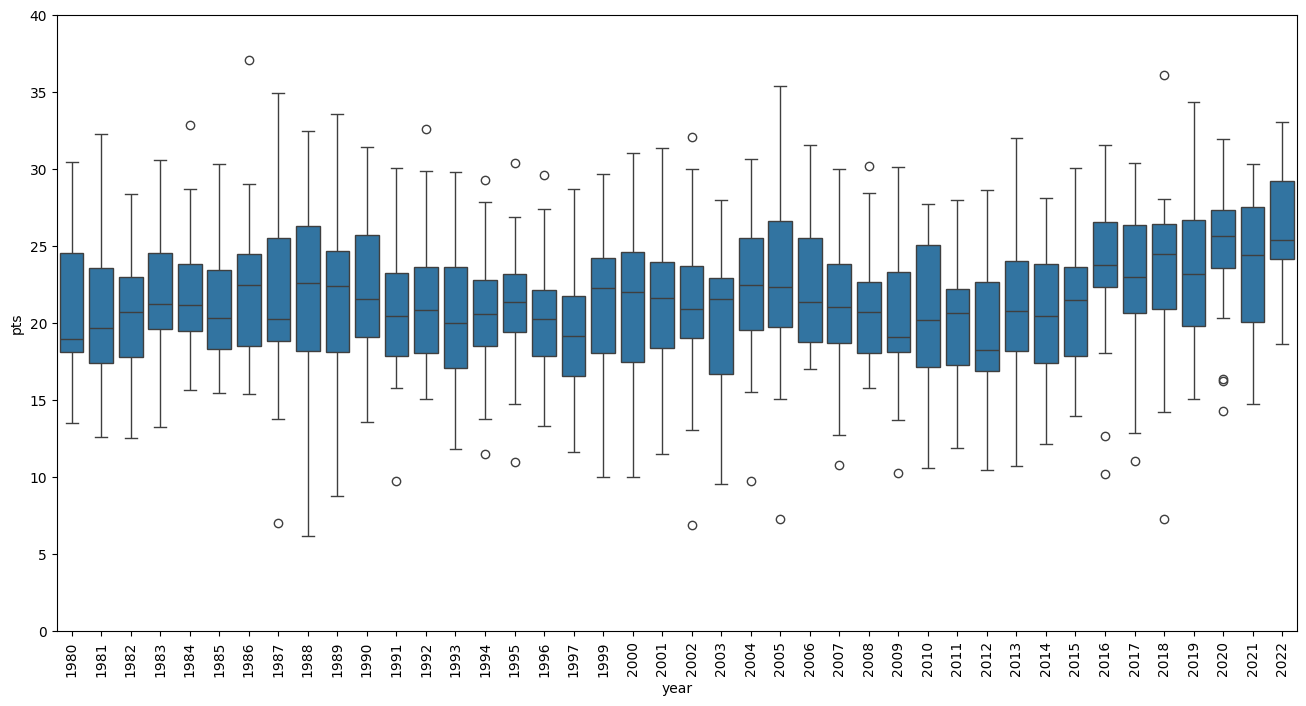

In [ ]:
data5 = pd.concat([df['pts'], df['year']], axis=1)
f= plt.figure(figsize=(16, 8))
fig = sns.boxplot(x='year', y="pts", data=data5)
fig.axis(ymin=0, ymax=40);
plt.xticks(rotation=90);

In [ ]:
df['min'] = pd.to_timedelta(df['min']).dt.total_seconds().div(3600)
df.head()

,first,last,team,year,games_played,min,fgm,fga,fg3m,fg3a,...,reb,ast,stl,blk,turnover,pf,pts,fg_pct,fg3_pct,ft_pct
0,Julius,Erving,PHI,1980,82.0,35.033333,9.68,18.59,0.05,0.22,...,8.01,4.44,2.62,1.73,3.40,2.84,24.56,0.521,0.220,0.787
1,Eddie,Johnson,ATL,1980,75.0,35.916667,7.64,15.16,0.08,0.32,...,2.39,5.47,1.54,0.11,2.70,2.53,19.08,0.504,0.249,0.784
2,Artis,Gilmore,CHI,1980,81.0,34.516667,6.67,9.93,0.00,0.00,...,10.06,2.15,0.77,2.43,3.31,3.58,17.89,0.672,0.000,0.706
3,Reggie,Theus,CHI,1980,81.0,34.333333,6.58,13.38,0.22,1.09,...,3.56,5.41,1.73,0.28,3.65,3.14,18.84,0.492,0.203,0.808
4,Larry,Bird,BOS,1980,82.0,39.500000,8.77,18.33,0.24,0.92,...,10.91,5.50,2.61,0.84,3.69,2.91,21.23,0.478,0.266,0.863


<ipython-input-24-80c02e5c8536>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


<Axes: >

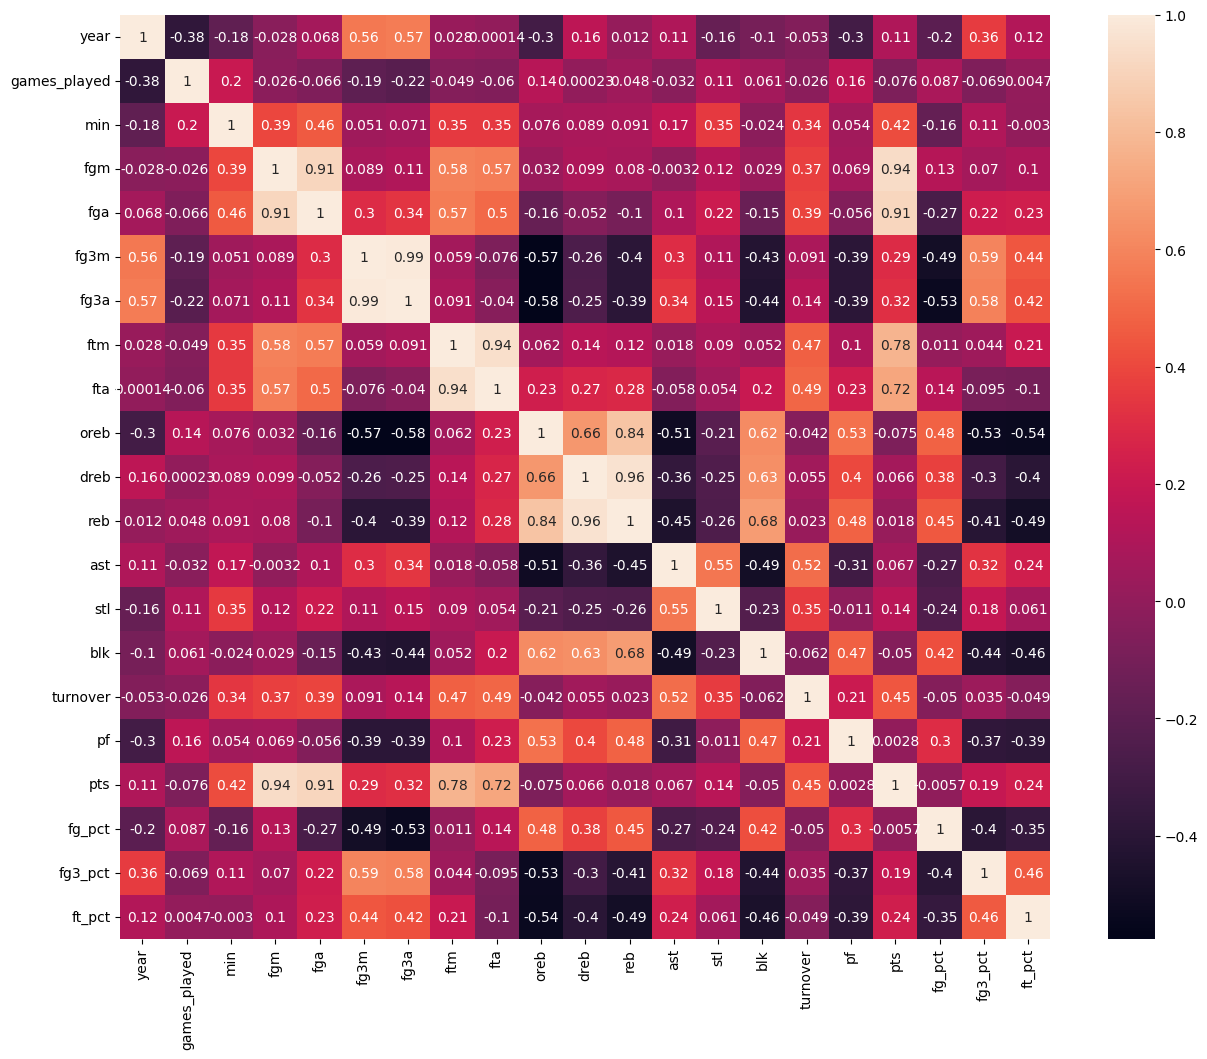

In [ ]:
#prikaz matrice korelacije
corr = df.corr()
f = plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True)

In [ ]:
correlation_matrix = df.corr()
print(correlation_matrix['pf']['oreb'])

0.5277022722090303


<ipython-input-25-a9e5ac98f3b3>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


Text(0.5, 1.0, 'Linearna zavisnost prosecnog broja ofanzivnih skokova po mecu sa prosecnim brojem licnih gresaka')

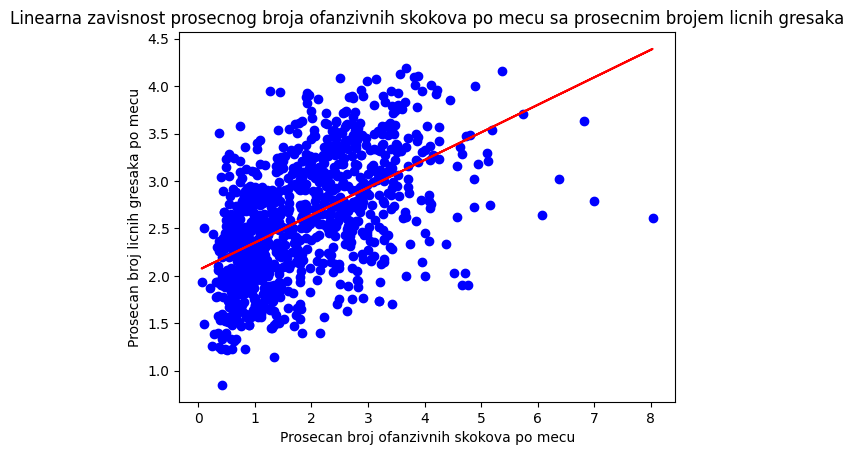

In [ ]:
x = df['oreb']
y = df['pf']
plt.scatter(x, y, color='blue', label='Data Points')
coefficients = np.polyfit(x, y, 1)
polynomial = np.poly1d(coefficients)
plt.plot(x, polynomial(x), color='red', label='Linear Regression')
plt.xlabel('Prosecan broj ofanzivnih skokova po mecu')
plt.ylabel('Prosecan broj licnih gresaka po mecu')
plt.title('Linearna zavisnost prosecnog broja ofanzivnih skokova po mecu sa prosecnim brojem licnih gresaka')

In [ ]:
personal_foul = df['pf']

In [ ]:
correlation_matrix = df.corrwith(personal_foul)
print(correlation_matrix)

year           -0.297136
games_played    0.161587
min             0.054377
fgm             0.068906
fga            -0.056074
fg3m           -0.392250
fg3a           -0.391061
ftm             0.101852
fta             0.227466
oreb            0.527702
dreb            0.397431
reb             0.480983
ast            -0.306735
stl            -0.011116
blk             0.473011
turnover        0.207767
pf              1.000000
pts             0.002780
fg_pct          0.300205
fg3_pct        -0.374283
ft_pct         -0.385005
dtype: float64


<ipython-input-28-ff8fedcc4d9a>:1: FutureWarning: The default value of numeric_only in DataFrame.corrwith is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corrwith(personal_foul)


In [ ]:
df_year = df.set_index('year')

<ipython-input-30-17762f006775>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(pf_2000, fit=norm)


Text(0, 0.5, 'Verovatnoća')

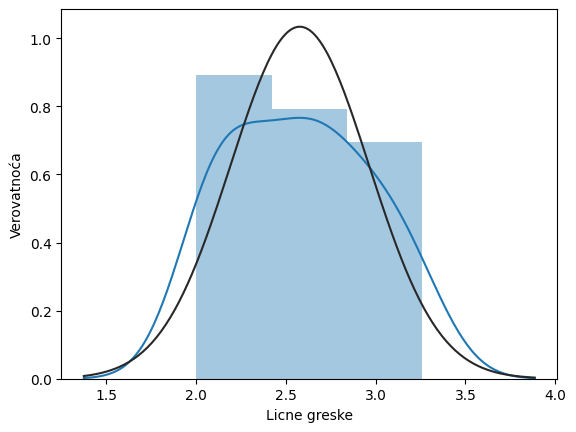

In [ ]:
#prikaz da li i koliko nasa raspodela verovatnoce prosecnog broja licnih gresaka u sezoni 2000. odstupa od normalne raspodele

import seaborn as sb
from scipy.stats import norm
pf_2000 = df_year.loc[2000,'pf']
sb.distplot(pf_2000, fit=norm)
plt.xlabel('Licne greske')
plt.ylabel('Verovatnoća')

In [ ]:
from scipy.stats import kurtosis
from scipy.stats import skew
#kurtosis je mera spljostenosti, skewness je mera asimetricnosti
#merimo odstupanje raspodele od normalne raspodele
#vidimo da je nasa raspodela niza od normalne raspodele (spljostenija), pa je kurtosis negativan
# takodje vidimo da je nasa raspodela malo nakrivljena na levu stranu, ima duzi desni rep, pa je u ovom slucaju asimetrija pozitivna

print('koef.asimetrije:  %.2f' % skew(df_year.loc[2000,'pf']))
print('koef.spljoštenosti:  %.2f' % kurtosis(df_year.loc[2000,'pf']))

koef.asimetrije:  0.16
koef.spljoštenosti:  -1.15


# Modeli regresije

In [ ]:
df.head()

,first,last,team,year,games_played,min,fgm,fga,fg3m,fg3a,...,reb,ast,stl,blk,turnover,pf,pts,fg_pct,fg3_pct,ft_pct
0,Julius,Erving,PHI,1980,82.0,35.033333,9.68,18.59,0.05,0.22,...,8.01,4.44,2.62,1.73,3.40,2.84,24.56,0.521,0.220,0.787
1,Eddie,Johnson,ATL,1980,75.0,35.916667,7.64,15.16,0.08,0.32,...,2.39,5.47,1.54,0.11,2.70,2.53,19.08,0.504,0.249,0.784
2,Artis,Gilmore,CHI,1980,81.0,34.516667,6.67,9.93,0.00,0.00,...,10.06,2.15,0.77,2.43,3.31,3.58,17.89,0.672,0.000,0.706
3,Reggie,Theus,CHI,1980,81.0,34.333333,6.58,13.38,0.22,1.09,...,3.56,5.41,1.73,0.28,3.65,3.14,18.84,0.492,0.203,0.808
4,Larry,Bird,BOS,1980,82.0,39.500000,8.77,18.33,0.24,0.92,...,10.91,5.50,2.61,0.84,3.69,2.91,21.23,0.478,0.266,0.863


In [ ]:
df.describe()

,year,games_played,min,fgm,fga,fg3m,fg3a,ftm,fta,oreb,...,reb,ast,stl,blk,turnover,pf,pts,fg_pct,fg3_pct,ft_pct
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,...,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,2001.089820,74.638723,35.927046,7.938263,16.273962,0.930050,2.582745,4.758134,6.058124,1.858523,...,7.211876,4.673972,1.321088,0.913673,2.739611,2.599770,21.564870,0.490682,0.274525,0.788469
std,12.514364,8.615857,3.031743,1.754162,3.653592,1.022842,2.649796,1.696613,2.133658,1.150622,...,3.137003,2.627055,0.567373,0.831964,0.711173,0.633464,4.900492,0.048065,0.143219,0.083086
min,1980.000000,19.000000,15.583333,2.290000,4.690000,0.000000,0.000000,0.760000,0.980000,0.060000,...,1.710000,0.600000,0.180000,0.000000,0.350000,0.850000,6.200000,0.358000,0.000000,0.355000
25%,1990.000000,71.000000,34.125000,6.740000,13.852500,0.040000,0.190000,3.520000,4.500000,0.900000,...,4.570000,2.690000,0.900000,0.310000,2.232500,2.112500,18.260000,0.458000,0.207250,0.750250
50%,2002.000000,78.000000,36.175000,7.915000,16.405000,0.570000,1.745000,4.590000,5.795000,1.610000,...,6.665000,4.060000,1.240000,0.630000,2.720000,2.575000,21.355000,0.487000,0.317500,0.799000
75%,2012.000000,81.000000,37.929167,9.137500,18.835000,1.550000,4.425000,5.825000,7.327500,2.610000,...,9.807500,6.047500,1.660000,1.270000,3.240000,3.067500,25.087500,0.518750,0.372000,0.846000
max,2022.000000,82.000000,43.733333,13.390000,27.820000,5.350000,13.180000,10.290000,12.250000,8.030000,...,18.660000,14.540000,3.660000,4.590000,5.730000,4.190000,37.090000,0.714000,1.000000,0.952000


In [ ]:
df.head()

,games_played,min,fgm,fga,fg3m,fg3a,ftm,fta,oreb,dreb,reb,ast,stl,blk,turnover,pts,fg_pct,fg3_pct,ft_pct
0,82.0,35.033333,9.68,18.59,0.05,0.22,5.15,6.54,2.28,5.83,8.01,4.44,2.62,1.73,3.40,24.56,0.521,0.220,0.787
1,75.0,35.916667,7.64,15.16,0.08,0.32,3.72,4.75,0.68,0.95,2.39,5.47,1.54,0.11,2.70,19.08,0.504,0.249,0.784
2,81.0,34.516667,6.67,9.93,0.00,0.00,4.56,6.46,3.42,6.84,10.06,2.15,0.77,2.43,3.31,17.89,0.672,0.000,0.706
3,81.0,34.333333,6.58,13.38,0.22,1.09,5.46,6.75,1.50,1.73,3.56,5.41,1.73,0.28,3.65,18.84,0.492,0.203,0.808
4,82.0,39.500000,8.77,18.33,0.24,0.92,3.45,4.00,2.71,10.53,10.91,5.50,2.61,0.84,3.69,21.23,0.478,0.266,0.863


In [ ]:
#vrednost koju zelimo da predvidimo smestamo u promenljivu y
# a to je prosecan broj licnih gresaka igraca po sezoni

y = df['pf']

In [ ]:
print(x.shape)

(1002, 19)


In [ ]:
x.describe()

,games_played,min,fgm,fga,fg3m,fg3a,ftm,fta,oreb,dreb,reb,ast,stl,blk,turnover,pts,fg_pct,fg3_pct,ft_pct
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,74.638723,35.927046,7.938263,16.273962,0.930050,2.582745,4.758134,6.058124,1.858523,5.358493,7.211876,4.673972,1.321088,0.913673,2.739611,21.564870,0.490682,0.274525,0.788469
std,8.615857,3.031743,1.754162,3.653592,1.022842,2.649796,1.696613,2.133658,1.150622,2.293323,3.137003,2.627055,0.567373,0.831964,0.711173,4.900492,0.048065,0.143219,0.083086
min,19.000000,15.583333,2.290000,4.690000,0.000000,0.000000,0.760000,0.980000,0.060000,0.790000,1.710000,0.600000,0.180000,0.000000,0.350000,6.200000,0.358000,0.000000,0.355000
25%,71.000000,34.125000,6.740000,13.852500,0.040000,0.190000,3.520000,4.500000,0.900000,3.382500,4.570000,2.690000,0.900000,0.310000,2.232500,18.260000,0.458000,0.207250,0.750250
50%,78.000000,36.175000,7.915000,16.405000,0.570000,1.745000,4.590000,5.795000,1.610000,5.045000,6.665000,4.060000,1.240000,0.630000,2.720000,21.355000,0.487000,0.317500,0.799000
75%,81.000000,37.929167,9.137500,18.835000,1.550000,4.425000,5.825000,7.327500,2.610000,7.132500,9.807500,6.047500,1.660000,1.270000,3.240000,25.087500,0.518750,0.372000,0.846000
max,82.000000,43.733333,13.390000,27.820000,5.350000,13.180000,10.290000,12.250000,8.030000,12.280000,18.660000,14.540000,3.660000,4.590000,5.730000,37.090000,0.714000,1.000000,0.952000


In [ ]:
y.describe()

count    1002.000000
mean        2.599770
std         0.633464
min         0.850000
25%         2.112500
50%         2.575000
75%         3.067500
max         4.190000
Name: pf, dtype: float64

Prvo cemo isprobati nekoliko modela linearne regresije i posmatracemo mere uspesnosti regresora, konkretno R2 skor i na osnovu njegove vrednosti odluciti koji model nam najvise odgovara. S obzirom da modeli linearne regresije imaju samo jedan hiperparametar fit_intercept=True ne mozemo koristiti funkciju GridSearchCV, pa moramo rucno ispitati koji model nam najvise odgovara.

In [ ]:
def model_evaluation(y_test, y_predicted, N, d):
    mse = mean_squared_error(y_test,y_predicted) #prosek kvadrata odstupanja predvidjene od prave vrednosti
    mae = mean_absolute_error(y_test,y_predicted) #srednje apsolutno odstupanje predvidjene od prave vrednosti
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_predicted) #R^2 skor prikazuje koliko se dobro podaci uklapaju u regresioni model
    r2_adj = 1-((1-r2)*(N-1))/(N-d-1) #prilagodjeni R^2, koristi se kada uporedjujemo modele koji sadrze razlicit broj obelezja ili su trenirani na razlicitom broju podataka

    # printing values
    print('Mean squared error: ', mse)
    print('Mean absolute error: ', mae)
    print('Root mean squared error: ', rmse)
    print('R2 score: ', r2)
    print('R2 adjusted score: ', r2_adj)

    # Uporedni prikaz nekoliko pravih i predvidjenih vrednosti
    res=pd.concat([pd.DataFrame(y_test.values), pd.DataFrame(y_predicted)], axis=1)
    res.columns = ['y', 'y_pred']
    print(res.head(20))
    return mse,mae,rmse,r2,r2_adj

In [ ]:
# podela skupa na trening i test podatke
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

## KNN regresor

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

### Bez standardizacije podataka

In [ ]:
parameters = {'n_neighbors':[1,2,3,4,5,8,10,9,11,12], 'metric':('hamming', 'euclidean', 'manhattan')}
regressor = KNeighborsRegressor()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ....metric=hamming, n_neighbors=1;, score=-0.693 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=1;, score=-0.516 total time=   0.0s
[CV 3/5] END ....metric=hamming, n_neighbors=1;, score=-0.522 total time=   0.0s
[CV 4/5] END ....metric=hamming, n_neighbors=1;, score=-0.518 total time=   0.0s
[CV 5/5] END ....metric=hamming, n_neighbors=1;, score=-0.500 total time=   0.0s
[CV 1/5] END ....metric=hamming, n_neighbors=2;, score=-0.229 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=2;, score=-0.280 total time=   0.0s
[CV 3/5] END ....metric=hamming, n_neighbors=2;, score=-0.240 total time=   0.0s
[CV 4/5] END ....metric=hamming, n_neighbors=2;, score=-0.101 total time=   0.0s
[CV 5/5] END ....metric=hamming, n_neighbors=2;, score=-0.321 total time=   0.0s
[CV 1/5] END ....metric=hamming, n_neighbors=3;, score=-0.018 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=3;

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'metric': ('hamming', 'euclidean', 'manhattan'),
                         'n_neighbors': [1, 2, 3, 4, 5, 8, 10, 9, 11, 12]},
             scoring='r2', verbose=3)

In [ ]:
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

najbolji skor:  0.361728425151564
najbolji hiperparametri:  {'metric': 'manhattan', 'n_neighbors': 8}


### Sa standardizacijom podataka

In [ ]:
# standardizacija
s = StandardScaler()
s.fit(x_train)
x_train_std = s.transform(x_train)
x_test_std = s.transform(x_test)
x_train_std = pd.DataFrame(x_train_std)
x_test_std = pd.DataFrame(x_test_std)

#x_train_std = pd.concat([x_train_std, x_train[dummy_feats].reset_index(drop=True)], axis=1)
#x_test_std = pd.concat([x_test_std, x_test[dummy_feats].reset_index(drop=True)], axis=1)


x_train_std.columns = list(x.columns)
x_test_std.columns = list(x.columns)
x_train_std.head()

,games_played,min,fgm,fga,fg3m,fg3a,ftm,fta,oreb,dreb,reb,ast,stl,blk,turnover,pts,fg_pct,fg3_pct,ft_pct
0,-0.856223,0.675156,-0.982239,-0.489919,0.599806,0.932454,-0.386854,-0.452401,-0.993747,-1.600816,-1.533903,0.309690,-0.424679,-0.968892,0.747220,-0.706851,-1.293263,0.214296,0.197241
1,0.284648,-1.158564,-0.311726,-0.557829,-0.711246,-0.774738,-0.725967,-0.725468,-1.216939,-1.103729,-1.252837,0.294421,-0.442494,-0.992782,-0.378894,-0.617477,0.612195,0.840436,-0.065068
2,0.740996,-1.654616,-0.862911,-0.788723,-0.895765,-0.951086,-1.082929,-1.059739,0.285311,-0.429419,-0.207526,-1.366091,-1.600486,-0.586649,-0.635477,-1.172001,-0.213503,-1.907624,-0.196223
3,0.740996,0.853512,0.608808,0.382044,0.774613,0.587264,2.141624,1.492023,-1.105343,0.850040,0.215651,-0.022412,0.216670,0.464520,1.018057,1.330469,0.400477,0.986536,1.389556
4,-2.339355,-0.339242,1.262274,1.039412,1.833167,1.667861,-0.630777,-0.965578,-0.770556,-0.675802,-0.775973,0.504371,0.181039,-0.264131,-0.478676,1.070472,0.315790,0.889136,1.592250


In [ ]:
parameters = {'n_neighbors':[1,2,3,4,5,8,10,9,11,12], 'metric':('hamming', 'euclidean', 'manhattan')}
regressor = KNeighborsRegressor()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_train_std, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ....metric=hamming, n_neighbors=1;, score=-0.693 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=1;, score=-0.516 total time=   0.0s
[CV 3/5] END ....metric=hamming, n_neighbors=1;, score=-0.522 total time=   0.0s
[CV 4/5] END ....metric=hamming, n_neighbors=1;, score=-0.518 total time=   0.0s
[CV 5/5] END ....metric=hamming, n_neighbors=1;, score=-0.500 total time=   0.0s
[CV 1/5] END ....metric=hamming, n_neighbors=2;, score=-0.229 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=2;, score=-0.280 total time=   0.0s
[CV 3/5] END ....metric=hamming, n_neighbors=2;, score=-0.240 total time=   0.0s
[CV 4/5] END ....metric=hamming, n_neighbors=2;, score=-0.101 total time=   0.0s
[CV 5/5] END ....metric=hamming, n_neighbors=2;, score=-0.321 total time=   0.0s
[CV 1/5] END ....metric=hamming, n_neighbors=3;, score=-0.018 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=3;

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'metric': ('hamming', 'euclidean', 'manhattan'),
                         'n_neighbors': [1, 2, 3, 4, 5, 8, 10, 9, 11, 12]},
             scoring='r2', verbose=3)

In [ ]:
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

najbolji skor:  0.48970584803676037
najbolji hiperparametri:  {'metric': 'manhattan', 'n_neighbors': 4}


## *Support Vector Regression*

In [ ]:
from sklearn.svm import SVR

### Bez standardizacije podataka

In [ ]:
from sklearn.model_selection import GridSearchCV

# definisanje hiperparamteara
param_grid = {'C': [0.1, 1, 50, 100],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': [ 'rbf', 'sigmoid','linear']}

grid = GridSearchCV(SVR(), param_grid, scoring='r2', refit = True,cv=5, verbose = 3)

# fitting the model for grid search
grid.fit(x_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.001 total time=   0.1s
[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.017 total time=   0.1s
[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.014 total time=   0.1s
[CV 4/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.008 total time=   0.1s
[CV 5/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.008 total time=   0.1s
[CV 1/5] END ...C=0.1, gamma=1, kernel=sigmoid;, score=-0.003 total time=   0.1s
[CV 2/5] END ...C=0.1, gamma=1, kernel=sigmoid;, score=-0.018 total time=   0.0s
[CV 3/5] END ...C=0.1, gamma=1, kernel=sigmoid;, score=-0.016 total time=   0.1s
[CV 4/5] END ...C=0.1, gamma=1, kernel=sigmoid;, score=-0.007 total time=   0.1s
[CV 5/5] END ...C=0.1, gamma=1, kernel=sigmoid;, score=-0.010 total time=   0.1s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.441 total time=   0.2s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 50, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'sigmoid', 'linear']},
             scoring='r2', verbose=3)

In [ ]:
print("najbolji skor: ", grid.best_score_)
print("najbolji hiperparametri: ", grid.best_params_)

najbolji skor:  0.4648840610403312
najbolji hiperparametri:  {'C': 50, 'gamma': 0.001, 'kernel': 'rbf'}


### Sa standardizacijom podataka

In [ ]:
# definisanje hiperparamteara
param_grid = {'C': [0.1, 1, 50, 100],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': [ 'rbf', 'sigmoid','linear']}

grid = GridSearchCV(SVR(), param_grid, scoring='r2', refit = True,cv=5, verbose = 3)

# fitting the model for grid search
grid.fit(x_train_std, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.021 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.003 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.003 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.018 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.019 total time=   0.0s
[CV 1/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-161.776 total time=   0.1s
[CV 2/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-148.135 total time=   0.1s
[CV 3/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-137.631 total time=   0.1s
[CV 4/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-184.104 total time=   0.1s
[CV 5/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-163.947 total time=   0.1s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.439 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 50, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'sigmoid', 'linear']},
             scoring='r2', verbose=3)

In [ ]:
print("najbolji skor: ", grid.best_score_)
print("najbolji hiperparametri: ", grid.best_params_)

najbolji skor:  0.5217426205681004
najbolji hiperparametri:  {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


## Linearna regresija

### *Ridge* regularizacija sa hipotezom drugog stepena sa interakcijama


In [ ]:
poly = PolynomialFeatures(interaction_only=False, degree=2, include_bias=True)
x_inter_train = poly.fit_transform(x_train_std)
x_inter_test = poly.transform(x_test_std)

In [ ]:
parameters = {'alpha':[1,5,7, 10]}
regressor = Ridge()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ...........................alpha=1;, score=0.469 total time=   0.0s
[CV 2/5] END ...........................alpha=1;, score=0.224 total time=   0.0s
[CV 3/5] END ...........................alpha=1;, score=0.396 total time=   0.0s
[CV 4/5] END ...........................alpha=1;, score=0.427 total time=   0.0s
[CV 5/5] END ...........................alpha=1;, score=0.461 total time=   0.0s
[CV 1/5] END ...........................alpha=5;, score=0.514 total time=   0.0s
[CV 2/5] END ...........................alpha=5;, score=0.292 total time=   0.0s
[CV 3/5] END ...........................alpha=5;, score=0.425 total time=   0.0s
[CV 4/5] END ...........................alpha=5;, score=0.469 total time=   0.0s
[CV 5/5] END ...........................alpha=5;, score=0.509 total time=   0.0s
[CV 1/5] END ...........................alpha=7;, score=0.518 total time=   0.0s
[CV 2/5] END ...........................alpha=7;,

In [ ]:
poly = PolynomialFeatures(interaction_only=True, degree=2, include_bias=True)
x_inter_train = poly.fit_transform(x_train_std)
x_inter_test = poly.transform(x_test_std)

parameters = {'alpha':[1,5,7, 10]}
regressor = Ridge()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ...........................alpha=1;, score=0.490 total time=   0.0s
[CV 2/5] END ...........................alpha=1;, score=0.281 total time=   0.0s
[CV 3/5] END ...........................alpha=1;, score=0.461 total time=   0.0s
[CV 4/5] END ...........................alpha=1;, score=0.419 total time=   0.0s
[CV 5/5] END ...........................alpha=1;, score=0.472 total time=   0.0s
[CV 1/5] END ...........................alpha=5;, score=0.522 total time=   0.0s
[CV 2/5] END ...........................alpha=5;, score=0.334 total time=   0.0s
[CV 3/5] END ...........................alpha=5;, score=0.464 total time=   0.0s
[CV 4/5] END ...........................alpha=5;, score=0.469 total time=   0.0s
[CV 5/5] END ...........................alpha=5;, score=0.513 total time=   0.0s
[CV 1/5] END ...........................alpha=7;, score=0.525 total time=   0.0s
[CV 2/5] END ...........................alpha=7;,

### *Lasso* regularizacija sa hipotezom trećeg stepena

In [ ]:
poly = PolynomialFeatures(interaction_only=True, degree=3, include_bias=True)
x_inter_train = poly.fit_transform(x_train_std)
x_inter_test = poly.transform(x_test_std)

parameters = {'alpha':[0.01,0.1,0.25,0.5,1,2,5,10]}
regressor = Lasso()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END ........................alpha=0.01;, score=0.505 total time=   0.3s
[CV 2/5] END ........................alpha=0.01;, score=0.397 total time=   0.2s
[CV 3/5] END ........................alpha=0.01;, score=0.466 total time=   0.2s
[CV 4/5] END ........................alpha=0.01;, score=0.520 total time=   0.3s
[CV 5/5] END ........................alpha=0.01;, score=0.572 total time=   0.2s
[CV 1/5] END .........................alpha=0.1;, score=0.288 total time=   0.1s
[CV 2/5] END .........................alpha=0.1;, score=0.298 total time=   0.1s
[CV 3/5] END .........................alpha=0.1;, score=0.260 total time=   0.1s
[CV 4/5] END .........................alpha=0.1;, score=0.335 total time=   0.1s
[CV 5/5] END .........................alpha=0.1;, score=0.370 total time=   0.1s
[CV 1/5] END ........................alpha=0.25;, score=0.099 total time=   0.1s
[CV 2/5] END ........................alpha=0.25;,

In [ ]:
poly = PolynomialFeatures(interaction_only=False, degree=3, include_bias=True)
x_inter_train = poly.fit_transform(x_train_std)
x_inter_test = poly.transform(x_test_std)

parameters = {'alpha':[0.01,0.1,0.25,0.5,1,2,5,10]}
regressor = Lasso()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END ........................alpha=0.01;, score=0.458 total time=   0.4s
[CV 2/5] END ........................alpha=0.01;, score=0.368 total time=   0.3s
[CV 3/5] END ........................alpha=0.01;, score=0.420 total time=   0.7s
[CV 4/5] END ........................alpha=0.01;, score=0.436 total time=   0.4s
[CV 5/5] END ........................alpha=0.01;, score=0.565 total time=   0.5s
[CV 1/5] END .........................alpha=0.1;, score=0.327 total time=   0.1s
[CV 2/5] END .........................alpha=0.1;, score=0.271 total time=   0.1s
[CV 3/5] END .........................alpha=0.1;, score=0.260 total time=   0.1s
[CV 4/5] END .........................alpha=0.1;, score=0.347 total time=   0.2s
[CV 5/5] END .........................alpha=0.1;, score=0.374 total time=   0.1s
[CV 1/5] END ........................alpha=0.25;, score=0.175 total time=   0.1s
[CV 2/5] END ........................alpha=0.25;,

### *Lasso* regularizacija sa hipotezom drugog stepena sa interakcijama

In [ ]:
poly = PolynomialFeatures(interaction_only=False, degree=2, include_bias=True)
x_inter_train = poly.fit_transform(x_train_std)
x_inter_test = poly.transform(x_test_std)

parameters = {'alpha':[0.01,0.1,0.25,0.5,1,2,5,10]}
regressor = Lasso()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END ........................alpha=0.01;, score=0.505 total time=   0.0s
[CV 2/5] END ........................alpha=0.01;, score=0.410 total time=   0.0s
[CV 3/5] END ........................alpha=0.01;, score=0.462 total time=   0.0s
[CV 4/5] END ........................alpha=0.01;, score=0.514 total time=   0.0s
[CV 5/5] END ........................alpha=0.01;, score=0.551 total time=   0.0s
[CV 1/5] END .........................alpha=0.1;, score=0.290 total time=   0.0s
[CV 2/5] END .........................alpha=0.1;, score=0.288 total time=   0.0s
[CV 3/5] END .........................alpha=0.1;, score=0.273 total time=   0.0s
[CV 4/5] END .........................alpha=0.1;, score=0.331 total time=   0.0s
[CV 5/5] END .........................alpha=0.1;, score=0.359 total time=   0.0s
[CV 1/5] END ........................alpha=0.25;, score=0.137 total time=   0.0s
[CV 2/5] END ........................alpha=0.25;,

# PCA redukcija dimenzionalnosti

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

s = StandardScaler()
X_std = s.fit_transform(x)
X_std

array([[ 8.54813845e-01, -2.94932306e-01,  9.93412451e-01, ...,
         6.31089158e-01, -3.80899926e-01, -1.76899567e-02],
       [ 4.19526318e-02, -3.42523282e-03, -1.70116802e-01, ...,
         2.77227190e-01, -1.78311976e-01, -5.38149634e-02],
       [ 7.38690814e-01, -4.65436444e-01, -7.23363555e-01, ...,
         3.77421605e+00, -1.91777403e+00, -9.93065137e-01],
       ...,
       [-2.16438495e+00, -7.89944318e-01, -3.29816896e-01, ...,
        -1.41885479e-02,  8.76542521e-01,  9.93810230e-01],
       [-1.90293429e-01, -8.39445520e-01,  7.99490909e-01, ...,
         4.43750469e-01,  3.45622377e-01, -1.01981639e-01],
       [-1.35152373e+00, -2.48398543e+00, -7.63288578e-01, ...,
         3.18858010e-01,  5.62181909e-01, -5.64828780e-03]])

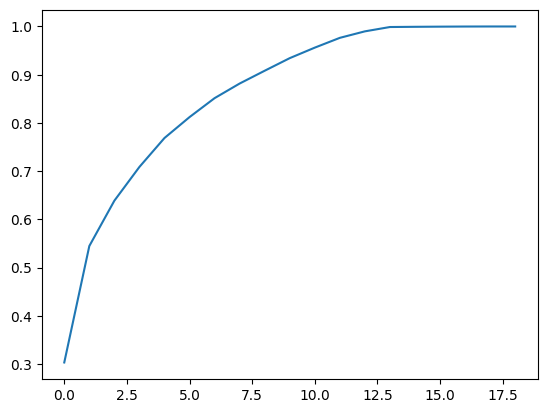

In [ ]:
pca = PCA(n_components=None)
pca.fit(X_std)
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [ ]:
print('Udeo objasnjene varijanse za dataset: %s'
      % str(pca.explained_variance_ratio_))

Udeo objasnjene varijanse za dataset: [3.03024746e-01 2.41552091e-01 9.40435060e-02 7.00387587e-02
 5.99715409e-02 4.33624950e-02 3.93102913e-02 3.03144946e-02
 2.65621425e-02 2.61082588e-02 2.18156874e-02 2.03076627e-02
 1.34703079e-02 8.98932801e-03 4.43534939e-04 3.25545573e-04
 2.46932582e-04 1.12602708e-04 7.28263148e-08]


In [ ]:
s=StandardScaler()
s.fit(x_train)
x_train_std = s.transform(x_train)
x_test_std = s.transform(x_test)

In [ ]:
pca=PCA(n_components=12)
pca.fit(x_train_std)
x_train_std_r = pca.transform(x_train_std)
x_test_std_r = pca.transform(x_test_std)

## PCA za kNN regresor

In [ ]:
parameters = {'n_neighbors':[1,2,3,4,5,8,10,9,11,12], 'metric':('hamming', 'euclidean', 'manhattan')}
regressor = KNeighborsRegressor()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_train_std_r, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ....metric=hamming, n_neighbors=1;, score=-0.006 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=1;, score=-0.061 total time=   0.0s
[CV 3/5] END ....metric=hamming, n_neighbors=1;, score=-0.009 total time=   0.0s
[CV 4/5] END ....metric=hamming, n_neighbors=1;, score=-0.986 total time=   0.0s
[CV 5/5] END ....metric=hamming, n_neighbors=1;, score=-0.692 total time=   0.0s
[CV 1/5] END ....metric=hamming, n_neighbors=2;, score=-0.075 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=2;, score=-0.281 total time=   0.0s
[CV 3/5] END ....metric=hamming, n_neighbors=2;, score=-0.495 total time=   0.0s
[CV 4/5] END ....metric=hamming, n_neighbors=2;, score=-0.503 total time=   0.0s
[CV 5/5] END ....metric=hamming, n_neighbors=2;, score=-0.368 total time=   0.0s
[CV 1/5] END ....metric=hamming, n_neighbors=3;, score=-0.089 total time=   0.0s
[CV 2/5] END ....metric=hamming, n_neighbors=3;

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'metric': ('hamming', 'euclidean', 'manhattan'),
                         'n_neighbors': [1, 2, 3, 4, 5, 8, 10, 9, 11, 12]},
             scoring='r2', verbose=3)

In [ ]:
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

najbolji skor:  0.4523703802567522
najbolji hiperparametri:  {'metric': 'euclidean', 'n_neighbors': 4}


## PCA za *Support Vector Regression*

In [ ]:
# definisanje hiperparamteara
param_grid = {'C': [0.1, 1, 50, 100],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': [ 'rbf', 'sigmoid','linear']}

grid = GridSearchCV(SVR(), param_grid, scoring='r2', refit = True,cv=5, verbose = 3)

# fitting the model for grid search
grid.fit(x_train_std_r, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.026 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.009 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.007 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.024 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.025 total time=   0.0s
[CV 1/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-172.228 total time=   0.1s
[CV 2/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-146.224 total time=   0.1s
[CV 3/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-132.295 total time=   0.1s
[CV 4/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-183.607 total time=   0.1s
[CV 5/5] END .C=0.1, gamma=1, kernel=sigmoid;, score=-165.654 total time=   0.1s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.340 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 50, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'sigmoid', 'linear']},
             scoring='r2', verbose=3)

In [ ]:
print("najbolji skor: ", grid.best_score_)
print("najbolji hiperparametri: ", grid.best_params_)

najbolji skor:  0.4601849540743535
najbolji hiperparametri:  {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


## PCA za linearnu regresiju

### *Ridge* regularizacija sa hipotezom drugog stepena sa interakcijama i PCA

In [ ]:
poly = PolynomialFeatures(interaction_only=False, degree=2, include_bias=True)
x_inter_train_r = poly.fit_transform(x_train_std_r)
x_inter_test_r = poly.transform(x_test_std_r)

In [ ]:
parameters = {'alpha':[1,5,7, 10]}
regressor = Ridge()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train_r, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ...........................alpha=1;, score=0.411 total time=   0.0s
[CV 2/5] END ...........................alpha=1;, score=0.372 total time=   0.0s
[CV 3/5] END ...........................alpha=1;, score=0.398 total time=   0.0s
[CV 4/5] END ...........................alpha=1;, score=0.327 total time=   0.0s
[CV 5/5] END ...........................alpha=1;, score=0.464 total time=   0.0s
[CV 1/5] END ...........................alpha=5;, score=0.413 total time=   0.0s
[CV 2/5] END ...........................alpha=5;, score=0.374 total time=   0.0s
[CV 3/5] END ...........................alpha=5;, score=0.399 total time=   0.0s
[CV 4/5] END ...........................alpha=5;, score=0.333 total time=   0.0s
[CV 5/5] END ...........................alpha=5;, score=0.468 total time=   0.0s
[CV 1/5] END ...........................alpha=7;, score=0.413 total time=   0.0s
[CV 2/5] END ...........................alpha=7;,

### *Lasso* regularizacija sa hipotezom trećeg stepena i PCA

In [ ]:
poly = PolynomialFeatures(interaction_only=True, degree=3, include_bias=True)
x_inter_train_r = poly.fit_transform(x_train_std_r)
x_inter_test_r = poly.transform(x_test_std_r)

parameters = {'alpha':[0.01,0.1,0.25,0.5,1,2,5,10]}
regressor = Lasso()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train_r, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END ........................alpha=0.01;, score=0.381 total time=   0.1s
[CV 2/5] END ........................alpha=0.01;, score=0.344 total time=   0.1s
[CV 3/5] END ........................alpha=0.01;, score=0.313 total time=   0.1s
[CV 4/5] END ........................alpha=0.01;, score=0.409 total time=   0.0s
[CV 5/5] END ........................alpha=0.01;, score=0.493 total time=   0.1s
[CV 1/5] END .........................alpha=0.1;, score=0.306 total time=   0.0s
[CV 2/5] END .........................alpha=0.1;, score=0.298 total time=   0.0s
[CV 3/5] END .........................alpha=0.1;, score=0.278 total time=   0.0s
[CV 4/5] END .........................alpha=0.1;, score=0.365 total time=   0.0s
[CV 5/5] END .........................alpha=0.1;, score=0.390 total time=   0.0s
[CV 1/5] END ........................alpha=0.25;, score=0.263 total time=   0.0s
[CV 2/5] END ........................alpha=0.25;,

### *Lasso* regularizacija sa hipotezom drugog stepena sa interakcijama i PCA

In [ ]:
poly = PolynomialFeatures(interaction_only=False, degree=2, include_bias=True)
x_inter_train_r = poly.fit_transform(x_train_std_r)
x_inter_test_r = poly.transform(x_test_std_r)

parameters = {'alpha':[0.01,0.1,0.25,0.5,1,2,5,10]}
regressor = Lasso()
clf = GridSearchCV(regressor, parameters, scoring='r2', cv=5, verbose=3)
clf.fit(x_inter_train_r, y_train)
print("najbolji skor: ", clf.best_score_)
print("najbolji hiperparametri: ", clf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END ........................alpha=0.01;, score=0.398 total time=   0.0s
[CV 2/5] END ........................alpha=0.01;, score=0.392 total time=   0.0s
[CV 3/5] END ........................alpha=0.01;, score=0.409 total time=   0.0s
[CV 4/5] END ........................alpha=0.01;, score=0.405 total time=   0.0s
[CV 5/5] END ........................alpha=0.01;, score=0.509 total time=   0.0s
[CV 1/5] END .........................alpha=0.1;, score=0.292 total time=   0.0s
[CV 2/5] END .........................alpha=0.1;, score=0.294 total time=   0.0s
[CV 3/5] END .........................alpha=0.1;, score=0.264 total time=   0.0s
[CV 4/5] END .........................alpha=0.1;, score=0.341 total time=   0.0s
[CV 5/5] END .........................alpha=0.1;, score=0.394 total time=   0.0s
[CV 1/5] END ........................alpha=0.25;, score=0.257 total time=   0.0s
[CV 2/5] END ........................alpha=0.25;,

# Konačni model

## KNN regresor

In [ ]:
#OBUKA KONACNOG MODELA KNN REGRESORA SA STANDARDIZACIJOM PODATAKA
knnr= KNeighborsRegressor(metric= 'manhattan', n_neighbors= 4)
knnr.fit(x_train_std, y_train)
y_pred = knnr.predict(x_test_std)
model_evaluation(y_test, y_pred, x_train_std.shape[0], x_train_std.shape[1])

Mean squared error:  0.21328496287128715
Mean absolute error:  0.35146039603960405
Root mean squared error:  0.4618278498220816
R2 score:  0.434735646633433
R2 adjusted score:  0.42254492845640146
       y  y_pred
0   2.39  2.2850
1   1.50  2.0975
2   3.63  3.4825
3   2.46  2.2925
4   1.83  1.9100
5   3.26  2.4725
6   2.77  2.1000
7   2.08  2.4125
8   2.43  2.3000
9   2.90  2.9100
10  1.74  2.2750
11  3.21  2.0975
12  2.31  2.5825
13  2.75  2.6000
14  2.44  2.6725
15  2.23  2.3925
16  3.15  1.8925
17  1.99  2.1975
18  2.89  2.7775
19  1.78  1.8875


(0.21328496287128715,
 0.35146039603960405,
 0.4618278498220816,
 0.434735646633433,
 0.42254492845640146)

## Support Vector Regression

In [ ]:
#OBUKA KONACNOG MODELA SVR SA STANDARDIZACIJOM PODATAKA
svregressor= SVR(C=1, gamma=0.1, kernel='rbf')
svregressor.fit(x_train_std, y_train)
y_pred = svregressor.predict(x_test_std)
model_evaluation(y_test, y_pred, x_train_std.shape[0], x_train_std.shape[1])

Mean squared error:  0.18402517772293733
Mean absolute error:  0.331521299725527
Root mean squared error:  0.4289815587212781
R2 score:  0.5122821989494903
R2 adjusted score:  0.5017638808791616
       y    y_pred
0   2.39  2.335581
1   1.50  2.005837
2   3.63  3.620462
3   2.46  2.365662
4   1.83  1.908596
5   3.26  2.475564
6   2.77  2.592350
7   2.08  2.302060
8   2.43  2.481524
9   2.90  2.764893
10  1.74  2.375183
11  3.21  2.402615
12  2.31  2.791755
13  2.75  2.762739
14  2.44  2.691849
15  2.23  2.323528
16  3.15  2.209324
17  1.99  2.037044
18  2.89  2.594722
19  1.78  2.181131


(0.18402517772293733,
 0.331521299725527,
 0.4289815587212781,
 0.5122821989494903,
 0.5017638808791616)

## Linearna regresija

In [ ]:
#OBUKA KONACNOG MODELA - LASSO SA HIPOTEZOM TRECEG STEPENA

# Inicijalizacija modela
lasso_model_2 = Lasso(alpha=0.01)

#Obuka
lasso_model_2.fit(x_inter_train, y_train)

# Testiranje
y_predicted = lasso_model_2.predict(x_inter_test)

# Evaluacija (racunanje mera uspesnosti)
model_evaluation(y_test, y_predicted, x_inter_train.shape[0], x_inter_train.shape[1])

Mean squared error:  0.2522004494109325
Mean absolute error:  0.40811144088026724
Root mean squared error:  0.5021956286258697
R2 score:  0.33159880548606624
R2 adjusted score:  0.12817235498182555
       y    y_pred
0   2.39  2.278343
1   1.50  2.284052
2   3.63  3.197687
3   2.46  2.439747
4   1.83  2.062457
5   3.26  2.577843
6   2.77  2.170519
7   2.08  2.234717
8   2.43  2.324964
9   2.90  2.675012
10  1.74  2.200606
11  3.21  2.733897
12  2.31  2.470367
13  2.75  2.691719
14  2.44  2.413043
15  2.23  2.243039
16  3.15  2.319259
17  1.99  2.173162
18  2.89  2.648719
19  1.78  2.678450


(0.2522004494109325,
 0.40811144088026724,
 0.5021956286258697,
 0.33159880548606624,
 0.12817235498182555)